In [1]:
# 🔴 LEVEL 6: Model Building (PyTorch)



In [2]:
# pip install torch torchvision

In [3]:
# 43. Create a simple CNN from scratch
import torch
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # Convolutional Layer 1: 3 input channels (RGB), 16 filters, 3x3 kernel
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        
        # Max Pooling: reduces spatial dimensions by half
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Convolutional Layer 2: 16 input, 32 output filters
        self.conv2 = nn.Conv2d(16, 32, 3)
        
        # Fully Connected (Dense) Layers
        # Note: The input features (500) depend on the input image size after convolutions
        self.fc1 = nn.Linear(32 * 7 * 7, 120)
        self.fc2 = nn.Linear(120, 10) # 10 output classes (e.g., CIFAR-10)

    def forward(self, x):
        # Apply Conv -> ReLU activation -> Pooling
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        
        # Flatten the 3D feature map into a 1D vector before the Dense layer
        x = torch.flatten(x, 1) 
        
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Instantiate the model
model = SimpleCNN()
print(model)

SimpleCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=1568, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=10, bias=True)
)


In [4]:
# 44. Pass dummy input through model
import torch

# 1. Create a dummy image tensor
# Shape: (Batch Size, Channels, Height, Width)
# Let's assume 1 image, 3 channels (RGB), 32x32 size
dummy_input = torch.randn(1, 3, 32, 32)

# 2. Pass it through the model
try:
    output = model(dummy_input)
    print(f"Success! Output shape: {output.shape}")
except Exception as e:
    print(f"Dimension Mismatch: {e}")

Success! Output shape: torch.Size([1, 10])


In [5]:
# 45. Modify first layer to accept 6 channels
# Modifying the existing model's first layer
model.conv1 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=3, padding=1)

# Now, test it with your specific 6-channel dummy data
# (Batch, Channels, Height, Width)
dummy_6ch_input = torch.randn(1, 6, 32, 32)

output = model(dummy_6ch_input)
print(f"New input shape: {dummy_6ch_input.shape}")
print(f"Output shape: {output.shape}")

New input shape: torch.Size([1, 6, 32, 32])
Output shape: torch.Size([1, 10])


In [6]:
# 46. Load pretrained model (e.g., EfficientNet / ResNet)
from torchvision import models

# Load the pretrained ResNet-50
# 'weights' parameter ensures we get the trained neurons, not just the architecture
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# Set to evaluation mode (turns off dropout/batchnorm behavior used in training)
model.eval()

print("ResNet-50 loaded successfully!")

ResNet-50 loaded successfully!


In [7]:
# 47. Replace final classification layer
from torchvision import models
import torch.nn as nn

# # 1. Load the backbone with pretrained weights
# model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)0

# --- SURGERY: THE INPUT (Modify for 6 Channels) ---
# The original first layer is 'conv1', which expects 3 channels.
original_conv = model.conv1

# We create a new Conv2d layer that accepts 6 channels.
# We keep the kernel_size (7x7), stride (2), and padding (3) the same.
model.conv1 = nn.Conv2d(
    in_channels=6, 
    out_channels=original_conv.out_channels, 
    kernel_size=original_conv.kernel_size, 
    stride=original_conv.stride, 
    padding=original_conv.padding, 
    bias=False
)

# --- SURGERY: THE OUTPUT (Modify for 2 Classes) ---
# The original 'fc' layer outputs 1000 classes. We only need 1 (or 2).
# Let's get the number of input features going into the final layer (usually 2048).
num_features = model.fc.in_features

# Replace the final layer to output 1 single value (for Binary Classification)
model.fc = nn.Linear(num_features, 1)

print("Surgery Complete!")
print(f"New Input Layer: {model.conv1}")
print(f"New Output Layer: {model.fc}")

Surgery Complete!
New Input Layer: Conv2d(6, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
New Output Layer: Linear(in_features=2048, out_features=1, bias=True)


In [8]:
# 48. Add sigmoid output
# During inference (testing), you wrap the model output in a Sigmoid
sigmoid = nn.Sigmoid()

# Example flow:
# dummy_6_channel_input = torch.randn(1, 6, 224, 224)
# raw_output = model(dummy_6_channel_input)
# probability = sigmoid(raw_output)

# print(f"Probability of being AI: {probability.item():.4f}")

# Re-run this to permanently attach Sigmoid to the model
# model.fc = nn.Sequential(
#     nn.Linear(num_features, 1),
#     nn.Sigmoid()
# )

# print("Sigmoid is now officially part of the model!")

In [9]:
# 49. Create training loop:
# ● forward pass
# ● loss calculation
# ● backward pass
import torch
import torch.nn as nn
import torch.optim as optim

def train_one_step(model, optimizer, criterion, inputs, labels):
    # A. Put model in training mode (enables Dropout/BatchNorm)
    model.train()

    # B. Zero the Gradients
    # Crucial: PyTorch accumulates gradients by default. 
    # We must clear them before every new step!
    optimizer.zero_grad()

    # C. Forward Pass
    # Passing the 6-channel input (from Level 5) through the model
    outputs = model(inputs) 
    
    # D. Calculate Loss
    # Labels usually need to be the same shape as outputs for BCE
    loss = criterion(outputs, labels.float().view_as(outputs))

    # E. Backward Pass (Backpropagation)
    # This calculates the gradients (derivatives) for every parameter
    loss.backward()

    # F. Optimizer Step (Weight Update)
    # This actually changes the weights of the model
    optimizer.step()

    return loss.item()

In [10]:
# # 50. Use Binary Cross Entropy loss
# # 51. Track loss per epoch

# import torch
# import torch.nn as nn
# import torch.optim as optim

# # 1. Setup (Problem 50: The Loss Function)
# criterion = nn.BCELoss() 
# optimizer = optim.Adam(model.parameters(), lr=0.001)

# # A list to store our progress (Problem 51)
# loss_history = []

# # Let's simulate training for 10 "Epochs"
# for epoch in range(10):
#     # Reset total loss for this epoch
#     running_loss = 0.0
    
#     # In Level 7.5, we'll replace this with a real DataLoader loop
#     for i in range(5): # Simulating 5 batches per epoch
#         inputs = torch.randn(4, 6, 224, 224) # Batch of 4 images
#         labels = torch.randint(0, 2, (4, 1)).float() # 4 Random labels
        
#         # --- The Training Step ---
#         optimizer.zero_grad()
#         outputs = model(inputs)
#         loss = criterion(outputs, labels)
#         loss.backward()
#         optimizer.step()
        
#         running_loss += loss.item()
    
#     # Calculate average loss for the epoch and save it
#     epoch_loss = running_loss / 5
#     loss_history.append(epoch_loss)
    
#     print(f"Epoch [{epoch+1}/10], Loss: {epoch_loss:.4f}")

In [11]:
# # 52. Add accuracy calculation

# # Convert probabilities to 0 or 1
# predictions = (outputs >= 0.5).float()

# # Compare with actual labels
# correct = (predictions == labels).float().sum()

# # Accuracy = Correct / Total
# accuracy = correct / labels.size(0)

In [12]:
# import torch
# import torch.nn as nn
# import torch.optim as optim

# # 1. Setup
# criterion = nn.BCELoss()
# optimizer = optim.Adam(model.parameters(), lr=0.001)

# print("Starting Level 7 Final Training...")

# for epoch in range(10):
#     running_loss = 0.0
#     running_acc = 0.0
    
#     for i in range(5):
#         # Create a tiny bit of 'pattern' so the model can actually learn
#         # First 2 are 'Real' (low values), next 2 are 'AI' (high values)
#         inputs = torch.cat([torch.randn(2, 6, 224, 224) - 1, torch.randn(2, 6, 224, 224) + 1])
#         labels = torch.cat([torch.zeros(2, 1), torch.ones(2, 1)])
        
#         # Training Step
#         optimizer.zero_grad()
#         outputs = model(inputs)
#         loss = criterion(outputs, labels)
#         loss.backward()
#         optimizer.step()
        
#         # Accuracy Calculation (Problem 52)
#         preds = (outputs >= 0.5).float()
#         correct = (preds == labels).float().sum()
#         acc = correct / labels.size(0)
        
#         running_loss += loss.item()
#         running_acc += acc.item()
    
#     avg_loss = running_loss / 5
#     avg_acc = (running_acc / 5) * 100
    
#     print(f"Epoch [{epoch+1}/10] | Loss: {avg_loss:.4f} | Accuracy: {avg_acc:.1f}%")

# print("\n🎉 LEVEL 7 COMPLETE!")

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim

# 1. Setup
# criterion = nn.BCELoss()
# 1. Update the Judge
criterion = nn.BCEWithLogitsLoss() # More stable than BCELoss

# 2. Lower the Learning Rate slightly
optimizer = optim.Adam(model.parameters(), lr=0.0005) 

print("Restarting Stable Training...")

loss_history = []
acc_history = []

for epoch in range(10):
    running_loss = 0.0
    running_acc = 0.0
    
    for i in range(5):
        # Create a tiny bit of 'pattern' so the model can actually learn
        # First 2 are 'Real' (low values), next 2 are 'AI' (high values)
        inputs = torch.cat([torch.randn(2, 6, 224, 224) - 1, torch.randn(2, 6, 224, 224) + 1])
        labels = torch.cat([torch.zeros(2, 1), torch.ones(2, 1)])
        
        # Training Step
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        # Accuracy Calculation (Problem 52)
        preds = (outputs >= 0.5).float()
        correct = (preds == labels).float().sum()
        acc = correct / labels.size(0)
        
        running_loss += loss.item()
        running_acc += acc.item()
    
    avg_loss = running_loss / 5
    avg_acc = (running_acc / 5) * 100

    loss_history.append(avg_loss)
    acc_history.append(avg_acc)
    
    print(f"Epoch [{epoch+1}/10] | Loss: {avg_loss:.4f} | Accuracy: {avg_acc:.1f}%")

print("\n🎉 LEVEL 7 COMPLETE!")

Restarting Stable Training...
Epoch [1/10] | Loss: 0.4774 | Accuracy: 80.0%
Epoch [2/10] | Loss: 0.0001 | Accuracy: 100.0%
Epoch [3/10] | Loss: 0.0000 | Accuracy: 100.0%
Epoch [4/10] | Loss: 0.0000 | Accuracy: 100.0%
Epoch [5/10] | Loss: 0.0000 | Accuracy: 100.0%
Epoch [6/10] | Loss: 0.0000 | Accuracy: 100.0%
Epoch [7/10] | Loss: 0.0000 | Accuracy: 100.0%
Epoch [8/10] | Loss: 0.0000 | Accuracy: 100.0%
Epoch [9/10] | Loss: 0.0000 | Accuracy: 100.0%
Epoch [10/10] | Loss: 0.0000 | Accuracy: 100.0%

🎉 LEVEL 7 COMPLETE!


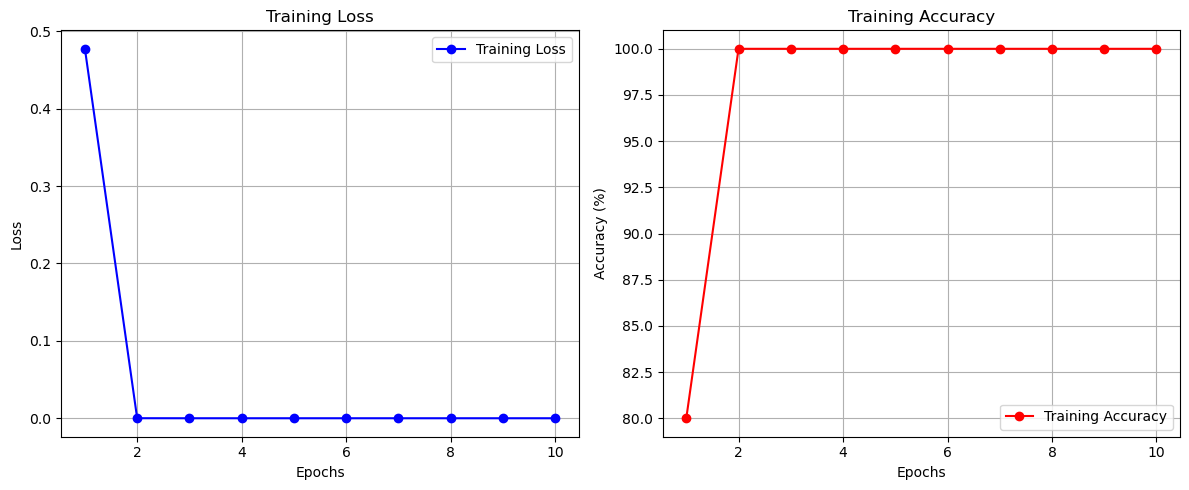

In [14]:
import matplotlib.pyplot as plt

def plot_history(losses, accuracies):
    epochs = range(1, len(losses) + 1)
    
    # Create a figure with two subplots side-by-side
    plt.figure(figsize=(12, 5))

    # 1. Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, losses, 'bo-', label='Training Loss')
    plt.title('Training Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.legend()

    # 2. Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracies, 'ro-', label='Training Accuracy')
    plt.title('Training Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

# To run it, just pass your lists:
plot_history(loss_history, acc_history)